<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/Support_Resistance_V3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support & Resistance Technical Dashboard — Version 3.1

Version 3.1 retains the corrected Wilder RSI/ADX, confirmed-pivot timing, ATR-based level clustering, and adds a structured recommendation engine.

The recommendation section now reports market regime, directional bias, confidence, conflicts, entry confirmation, invalidation, ATR-based risk levels, targets, estimated reward-to-risk, and a frequent **WAIT / NO TRADE** outcome.

**Important:** Historical pivots are recorded with a separate confirmation date so a backtest does not use future candles. The output is a technical research snapshot, not financial advice.


In [ ]:
!pip -q install yfinance scipy

Enter ticker (for example: CRM, NVDA, AAPL): Klac
KLAC TECHNICAL ANALYSIS - VERSION 3.1
Data through: 2026-08-28 | Adjusted close: $175.54

Trend and momentum
  SMA 20 / 50 / 200: 192.02 / 213.47 / 169.68
  RSI 14: 35.9 | MFI 14: 43.9
  MACD / Signal / Histogram: -7.412 / -6.603 / -0.809
  ADX / +DI / -DI: 18.0 / 18.6 / 32.4
  ATR 14: $10.06 (5.73% of price) | RVOL: 1.02x

Confirmed current zones
  Support $169.09 | distance 3.67% | touches 3 | score 6.01
  Support $160.93 | distance 8.32% | touches 2 | score 3.68
  Support $137.11 | distance 21.89% | touches 1 | score 1.84
  Support $129.27 | distance 26.36% | touches 3 | score 4.93
  Resistance $193.47 | distance 10.21% | touches 1 | score 1.93
  Resistance $214.56 | distance 22.23% | touches 1 | score 2.41
  Resistance $307.02 | distance 74.90% | touches 1 | score 2.19

Evidence score
  Neutral / mixed (-1 on a -7 to +7 scale)
  [-1] MACD momentum is bearish.
  [-1] RSI 35.9 shows weak momentum.
  [+0] ADX 18.0 indicates limited tre

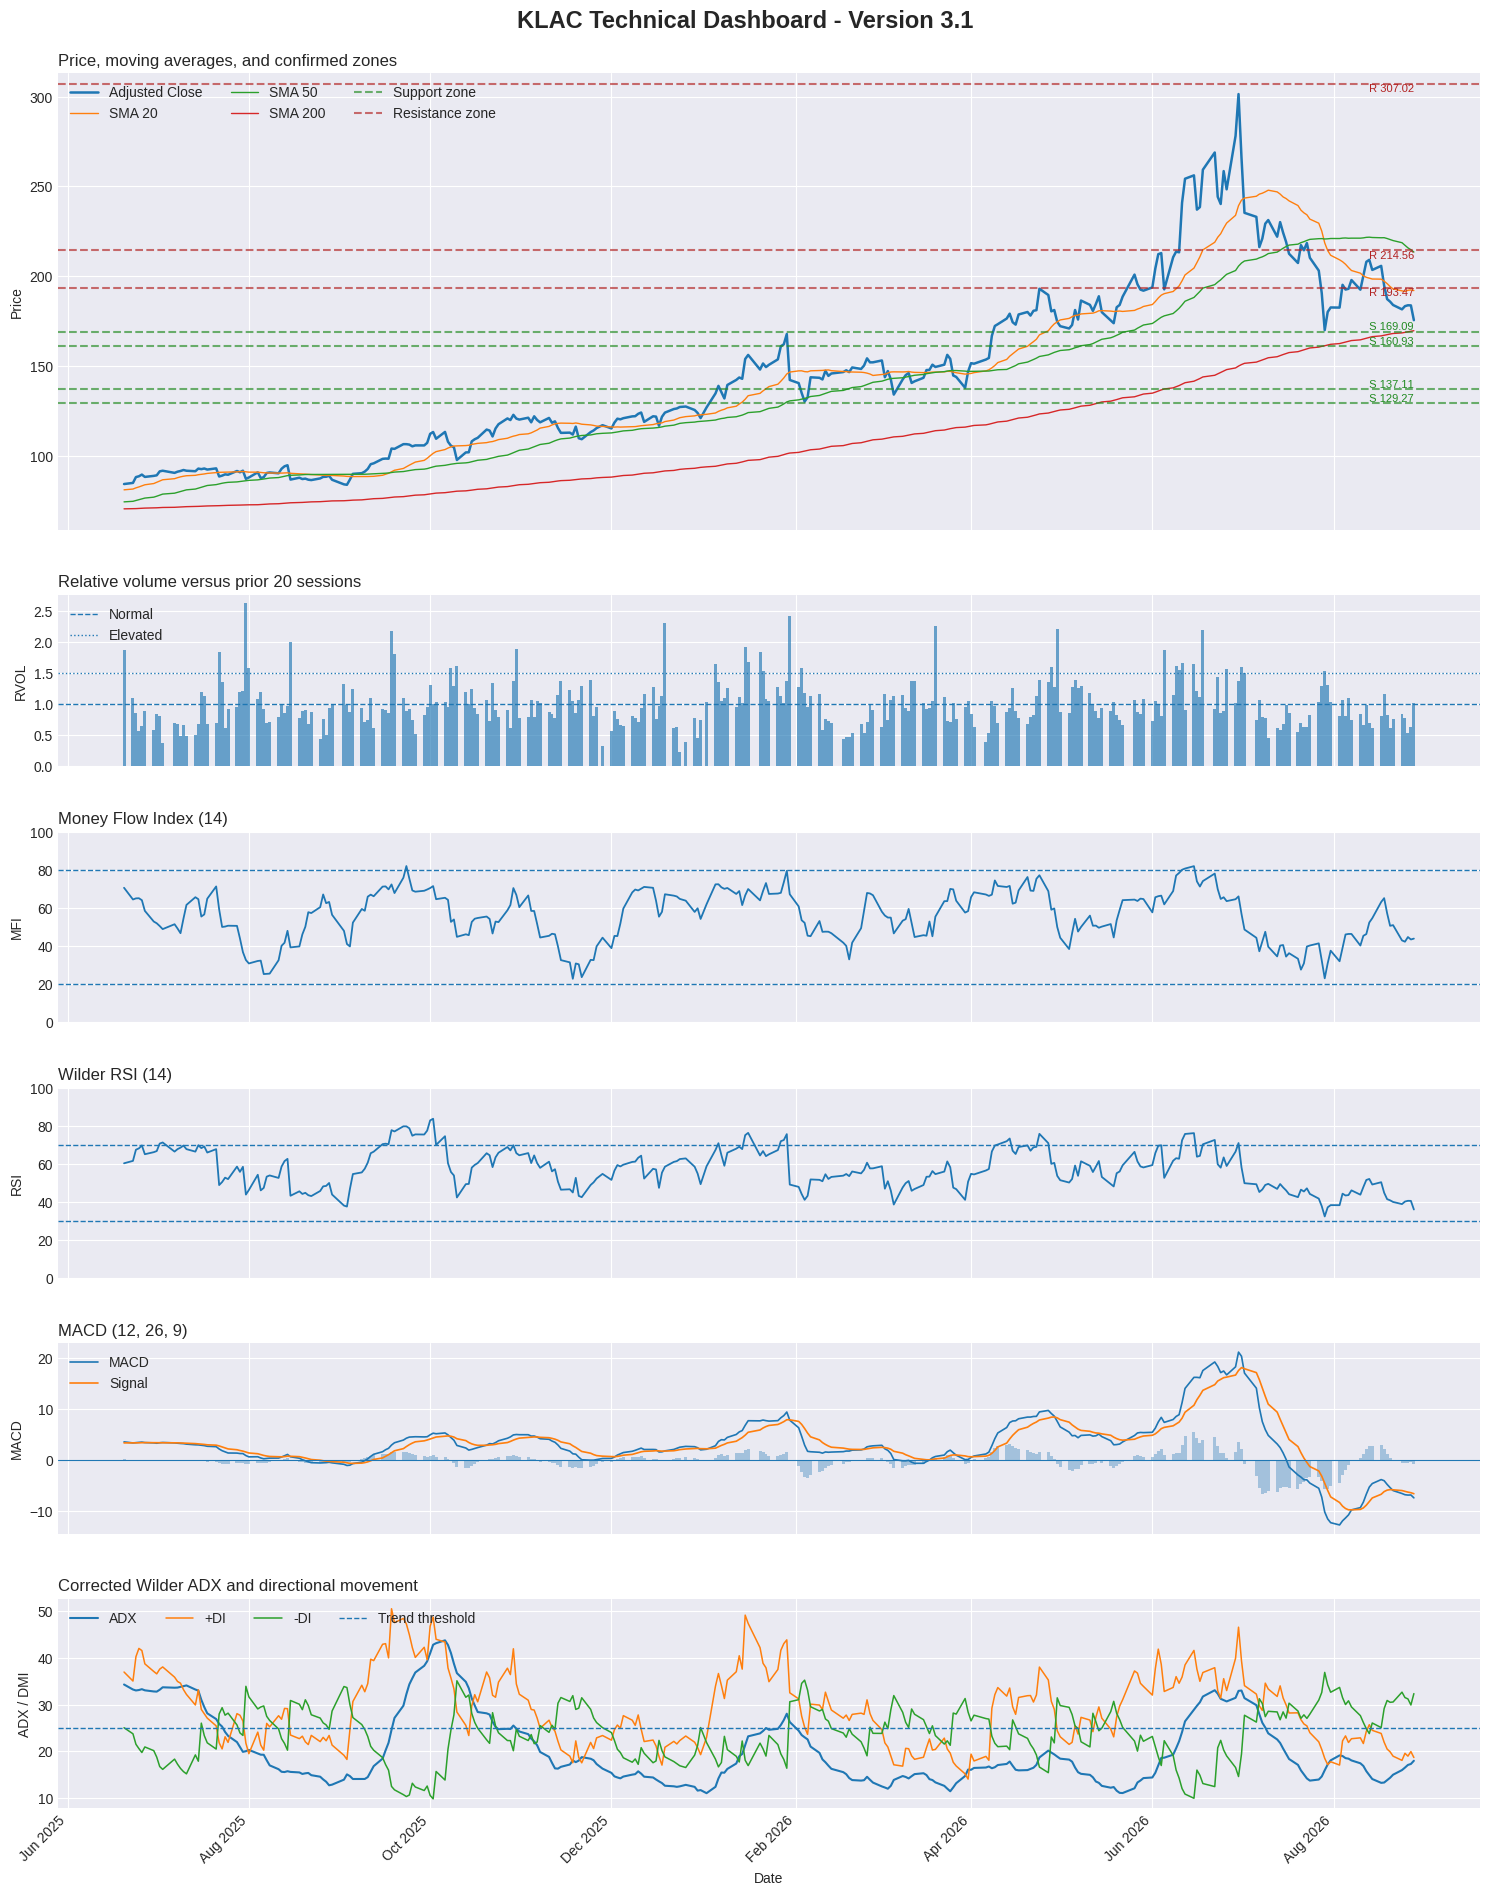

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from scipy.signal import argrelextrema


# =========================
# VERSION 3.1 CONFIGURATION
# =========================
DEFAULT_PERIOD = "3y"
DEFAULT_INTERVAL = "1d"
PIVOT_WINDOW = 10
MAX_LEVELS_EACH_SIDE = 4


def download_stock_data(symbol, period=DEFAULT_PERIOD, interval=DEFAULT_INTERVAL):
    """Download adjusted OHLCV data with explicit yfinance settings."""
    df = yf.download(
        symbol,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False,
        group_by="column",
    )
    if df.empty:
        raise ValueError(f"No price data returned for {symbol}.")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    required = ["Open", "High", "Low", "Close", "Volume"]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[required].dropna(subset=["Open", "High", "Low", "Close"]).copy()
    df.index = pd.to_datetime(df.index)
    return df


def wilder_average(series, period=14):
    """Wilder-style exponential smoothing."""
    return series.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()


def calculate_indicators(df):
    """Calculate trend, momentum, volume, volatility, and DMI/ADX indicators."""
    data = df.copy()

    # Moving averages
    data["SMA_20"] = data["Close"].rolling(20).mean()
    data["SMA_50"] = data["Close"].rolling(50).mean()
    data["SMA_200"] = data["Close"].rolling(200).mean()

    # RSI (Wilder)
    delta = data["Close"].diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)
    avg_gain = wilder_average(gains, 14)
    avg_loss = wilder_average(losses, 14)
    rs = avg_gain / avg_loss.replace(0, np.nan)
    data["RSI_14"] = 100 - (100 / (1 + rs))
    data.loc[(avg_loss == 0) & (avg_gain > 0), "RSI_14"] = 100
    data.loc[(avg_gain == 0) & (avg_loss > 0), "RSI_14"] = 0

    # MACD
    ema_12 = data["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = data["Close"].ewm(span=26, adjust=False).mean()
    data["MACD"] = ema_12 - ema_26
    data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()
    data["MACD_Hist"] = data["MACD"] - data["MACD_Signal"]

    # True Range / ATR (Wilder)
    previous_close = data["Close"].shift(1)
    true_range = pd.concat(
        [
            data["High"] - data["Low"],
            (data["High"] - previous_close).abs(),
            (data["Low"] - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    data["TR"] = true_range
    data["ATR_14"] = wilder_average(true_range, 14)

    # Correct directional movement and ADX
    up_move = data["High"].diff()
    down_move = -data["Low"].diff()
    plus_dm = up_move.where((up_move > down_move) & (up_move > 0), 0.0)
    minus_dm = down_move.where((down_move > up_move) & (down_move > 0), 0.0)

    smoothed_plus_dm = wilder_average(plus_dm, 14)
    smoothed_minus_dm = wilder_average(minus_dm, 14)
    atr_safe = data["ATR_14"].replace(0, np.nan)
    data["Plus_DI"] = 100 * smoothed_plus_dm / atr_safe
    data["Minus_DI"] = 100 * smoothed_minus_dm / atr_safe
    di_sum = (data["Plus_DI"] + data["Minus_DI"]).replace(0, np.nan)
    dx = 100 * (data["Plus_DI"] - data["Minus_DI"]).abs() / di_sum
    data["ADX"] = wilder_average(dx, 14)

    # Money Flow Index
    typical_price = (data["High"] + data["Low"] + data["Close"]) / 3
    raw_money_flow = typical_price * data["Volume"]
    direction = typical_price.diff()
    positive_flow = raw_money_flow.where(direction > 0, 0.0)
    negative_flow = raw_money_flow.where(direction < 0, 0.0)
    positive_sum = positive_flow.rolling(14).sum()
    negative_sum = negative_flow.rolling(14).sum().replace(0, np.nan)
    money_ratio = positive_sum / negative_sum
    data["MFI_14"] = 100 - (100 / (1 + money_ratio))
    data.loc[(negative_sum.isna()) & (positive_sum > 0), "MFI_14"] = 100

    # Relative volume compared with PREVIOUS 20 complete sessions
    data["Volume_Avg_20_Prior"] = data["Volume"].shift(1).rolling(20).mean()
    data["RVOL"] = data["Volume"] / data["Volume_Avg_20_Prior"].replace(0, np.nan)

    return data


def identify_confirmed_pivots(df, order=PIVOT_WINDOW):
    """
    Find local pivots and record when each pivot becomes knowable.

    A pivot occurring at index i is only confirmed at index i + order. This prevents
    a backtest or signal report from pretending the pivot was known on its pivot date.
    """
    pivots = []
    lows = df["Low"].to_numpy()
    highs = df["High"].to_numpy()

    low_positions = argrelextrema(lows, np.less_equal, order=order)[0]
    high_positions = argrelextrema(highs, np.greater_equal, order=order)[0]

    for position in low_positions:
        confirmation_position = position + order
        if confirmation_position < len(df):
            pivots.append(
                {
                    "kind": "low",
                    "price": float(lows[position]),
                    "pivot_date": df.index[position],
                    "confirmed_date": df.index[confirmation_position],
                    "position": int(position),
                }
            )

    for position in high_positions:
        confirmation_position = position + order
        if confirmation_position < len(df):
            pivots.append(
                {
                    "kind": "high",
                    "price": float(highs[position]),
                    "pivot_date": df.index[position],
                    "confirmed_date": df.index[confirmation_position],
                    "position": int(position),
                }
            )

    return pd.DataFrame(pivots).sort_values("confirmed_date").reset_index(drop=True)


def cluster_and_score_levels(df, pivots, atr_multiple=0.75, max_age_bars=504):
    """Cluster confirmed pivot prices using an ATR-scaled distance and score each zone."""
    if pivots.empty:
        return pd.DataFrame(columns=["price", "touches", "score", "last_pivot_date", "source_types"])

    latest_atr = float(df["ATR_14"].dropna().iloc[-1])
    latest_price = float(df["Close"].iloc[-1])
    tolerance = max(latest_atr * atr_multiple, latest_price * 0.004)
    cutoff_position = max(0, len(df) - max_age_bars)
    recent = pivots[pivots["position"] >= cutoff_position].copy()

    clusters = []
    for pivot in recent.sort_values("price").to_dict("records"):
        best_cluster = None
        best_distance = None
        for cluster in clusters:
            distance = abs(pivot["price"] - cluster["weighted_price"])
            if distance <= tolerance and (best_distance is None or distance < best_distance):
                best_cluster = cluster
                best_distance = distance

        recency_bars = max(0, len(df) - 1 - int(pivot["position"]))
        recency_weight = float(np.exp(-recency_bars / 180))
        pivot_weight = 1.0 + recency_weight

        if best_cluster is None:
            clusters.append(
                {
                    "weighted_sum": pivot["price"] * pivot_weight,
                    "weight_sum": pivot_weight,
                    "weighted_price": pivot["price"],
                    "touches": 1,
                    "recency_score": recency_weight,
                    "last_pivot_date": pivot["pivot_date"],
                    "source_types": {pivot["kind"]},
                }
            )
        else:
            best_cluster["weighted_sum"] += pivot["price"] * pivot_weight
            best_cluster["weight_sum"] += pivot_weight
            best_cluster["weighted_price"] = best_cluster["weighted_sum"] / best_cluster["weight_sum"]
            best_cluster["touches"] += 1
            best_cluster["recency_score"] += recency_weight
            best_cluster["last_pivot_date"] = max(best_cluster["last_pivot_date"], pivot["pivot_date"])
            best_cluster["source_types"].add(pivot["kind"])

    rows = []
    for cluster in clusters:
        touches = cluster["touches"]
        score = touches + 1.5 * cluster["recency_score"]
        rows.append(
            {
                "price": float(cluster["weighted_price"]),
                "touches": int(touches),
                "score": float(score),
                "last_pivot_date": cluster["last_pivot_date"],
                "source_types": ",".join(sorted(cluster["source_types"])),
                "tolerance": tolerance,
            }
        )

    return pd.DataFrame(rows).sort_values(["score", "touches"], ascending=False).reset_index(drop=True)


def select_current_levels(levels, current_price, max_levels=MAX_LEVELS_EACH_SIDE):
    """Classify zones by current position instead of permanently labeling highs/lows."""
    supports = levels[levels["price"] < current_price].copy()
    resistances = levels[levels["price"] > current_price].copy()

    supports["distance_pct"] = 100 * (current_price - supports["price"]) / current_price
    resistances["distance_pct"] = 100 * (resistances["price"] - current_price) / current_price

    supports = supports.sort_values(["distance_pct", "score"], ascending=[True, False]).head(max_levels)
    resistances = resistances.sort_values(["distance_pct", "score"], ascending=[True, False]).head(max_levels)
    return supports, resistances


def latest_cross_date(df, left, right, direction="above"):
    valid = df[[left, right]].dropna()
    if valid.empty:
        return None
    if direction == "above":
        mask = (valid[left].shift(1) <= valid[right].shift(1)) & (valid[left] > valid[right])
    else:
        mask = (valid[left].shift(1) >= valid[right].shift(1)) & (valid[left] < valid[right])
    dates = valid.index[mask]
    return dates[-1] if len(dates) else None


def build_signal_score(df, supports, resistances):
    """Create a transparent, bounded evidence score rather than a single-rule verdict."""
    required = [
        "Close", "Open", "SMA_20", "SMA_50", "RSI_14", "MACD",
        "MACD_Signal", "MACD_Hist", "ADX", "Plus_DI", "Minus_DI", "ATR_14"
    ]
    latest = df.dropna(subset=required).iloc[-1]
    score = 0
    evidence = []

    # Trend structure: maximum +/-3
    if pd.notna(latest["SMA_200"]):
        if latest["Close"] > latest["SMA_20"] > latest["SMA_50"] > latest["SMA_200"]:
            score += 3
            evidence.append((+3, "Price and moving averages are in bullish alignment."))
        elif latest["Close"] < latest["SMA_20"] < latest["SMA_50"] < latest["SMA_200"]:
            score -= 3
            evidence.append((-3, "Price and moving averages are in bearish alignment."))
        elif latest["Close"] > latest["SMA_50"] and latest["Close"] > latest["SMA_200"]:
            score += 1
            evidence.append((+1, "Price is above the medium- and long-term averages."))
        elif latest["Close"] < latest["SMA_50"] and latest["Close"] < latest["SMA_200"]:
            score -= 1
            evidence.append((-1, "Price is below the medium- and long-term averages."))

    # Momentum: MACD +/-1
    if latest["MACD"] > latest["MACD_Signal"] and latest["MACD_Hist"] > 0:
        score += 1
        evidence.append((+1, "MACD momentum is bullish."))
    elif latest["MACD"] < latest["MACD_Signal"] and latest["MACD_Hist"] < 0:
        score -= 1
        evidence.append((-1, "MACD momentum is bearish."))

    # RSI: momentum, not an automatic reversal signal
    rsi = latest["RSI_14"]
    if 55 <= rsi <= 70:
        score += 1
        evidence.append((+1, f"RSI {rsi:.1f} shows constructive momentum."))
    elif 30 <= rsi <= 45:
        score -= 1
        evidence.append((-1, f"RSI {rsi:.1f} shows weak momentum."))
    elif rsi > 75:
        evidence.append((0, f"RSI {rsi:.1f} is extended; extension is not an automatic sell signal."))
    elif rsi < 25:
        evidence.append((0, f"RSI {rsi:.1f} is deeply oversold; oversold is not an automatic buy signal."))

    # ADX confirms direction only when trend strength is meaningful
    if latest["ADX"] >= 25:
        direction = 1 if latest["Plus_DI"] > latest["Minus_DI"] else -1
        score += direction
        evidence.append((direction, f"ADX {latest['ADX']:.1f} confirms a {'bullish' if direction > 0 else 'bearish'} directional trend."))
    else:
        evidence.append((0, f"ADX {latest['ADX']:.1f} indicates limited trend strength."))

    # Volume confirms participation but does not identify institutions
    if pd.notna(latest["RVOL"]) and latest["RVOL"] >= 1.5:
        direction = 1 if latest["Close"] >= latest["Open"] else -1
        score += direction
        evidence.append((direction, f"RVOL {latest['RVOL']:.2f}x confirms elevated participation on a {'positive' if direction > 0 else 'negative'} session."))
    elif pd.notna(latest["RVOL"]) and latest["RVOL"] < 0.8:
        evidence.append((0, f"RVOL {latest['RVOL']:.2f}x is light, reducing confidence in price moves."))

    # Location versus nearest confirmed levels: +/-1
    atr = latest["ATR_14"]
    nearest_support = supports.iloc[0] if not supports.empty else None
    nearest_resistance = resistances.iloc[0] if not resistances.empty else None
    if nearest_support is not None and abs(latest["Close"] - nearest_support["price"]) <= atr:
        score += 1
        evidence.append((+1, "Price is within one ATR of a confirmed support zone."))
    if nearest_resistance is not None and abs(nearest_resistance["price"] - latest["Close"]) <= atr:
        score -= 1
        evidence.append((-1, "Price is within one ATR of a confirmed resistance zone."))

    score = int(np.clip(score, -7, 7))
    if score >= 4:
        stance = "Bullish bias"
    elif score >= 2:
        stance = "Moderately bullish"
    elif score <= -4:
        stance = "Bearish bias"
    elif score <= -2:
        stance = "Moderately bearish"
    else:
        stance = "Neutral / mixed"

    return score, stance, evidence


def detect_breakout(df, level_price, direction, atr_buffer=0.20, confirmation_closes=2):
    """Require buffered, multi-close confirmation; never call a one-tick move a breakout."""
    recent = df.dropna(subset=["Close", "ATR_14"]).tail(confirmation_closes)
    if len(recent) < confirmation_closes:
        return False
    buffer = recent["ATR_14"] * atr_buffer
    if direction == "above":
        return bool((recent["Close"] > level_price + buffer).all())
    return bool((recent["Close"] < level_price - buffer).all())


def classify_market_regime(df):
    """Classify the latest environment without pretending ADX alone proves a range."""
    latest = df.dropna(subset=["Close", "SMA_20", "SMA_50", "ADX", "Plus_DI", "Minus_DI", "ATR_14"]).iloc[-1]
    atr_pct = 100 * latest["ATR_14"] / latest["Close"]
    ma_gap_atr = abs(latest["SMA_20"] - latest["SMA_50"]) / latest["ATR_14"] if latest["ATR_14"] > 0 else 0

    if latest["ADX"] >= 25 and ma_gap_atr >= 0.5:
        direction = "bullish" if latest["Plus_DI"] > latest["Minus_DI"] else "bearish"
        regime = f"Trending ({direction})"
    elif latest["ADX"] < 20 and ma_gap_atr < 0.75:
        regime = "Range / low-trend"
    else:
        regime = "Transitional / developing"

    volatility = "high" if atr_pct >= 3.0 else "moderate" if atr_pct >= 1.5 else "low"
    return regime, volatility, float(atr_pct)


def identify_conflicts(df, score, supports, resistances):
    """Surface disagreements instead of hiding them inside a net score."""
    latest = df.iloc[-1]
    conflicts = []
    bullish_trend = pd.notna(latest["SMA_200"]) and latest["Close"] > latest["SMA_50"] > latest["SMA_200"]
    bearish_trend = pd.notna(latest["SMA_200"]) and latest["Close"] < latest["SMA_50"] < latest["SMA_200"]
    bullish_momentum = latest["MACD_Hist"] > 0 and latest["RSI_14"] >= 50
    bearish_momentum = latest["MACD_Hist"] < 0 and latest["RSI_14"] <= 50

    if bullish_trend and bearish_momentum:
        conflicts.append("The broader trend is bullish, but short-term momentum is weakening.")
    if bearish_trend and bullish_momentum:
        conflicts.append("The broader trend is bearish, but short-term momentum is improving.")
    if latest["ADX"] < 20 and abs(score) >= 3:
        conflicts.append("Directional indicators agree, but trend strength remains weak.")
    if pd.notna(latest["RVOL"]) and latest["RVOL"] < 0.8 and abs(score) >= 3:
        conflicts.append("The directional case lacks meaningful volume confirmation.")
    if latest["RSI_14"] > 75 and score > 0:
        conflicts.append("Bullish momentum is extended, increasing pullback risk.")
    if latest["RSI_14"] < 25 and score < 0:
        conflicts.append("Bearish momentum is deeply stretched, increasing rebound risk.")

    atr = latest["ATR_14"]
    if not resistances.empty and resistances.iloc[0]["price"] - latest["Close"] <= atr and score > 0:
        conflicts.append("Nearest resistance is less than one ATR away, limiting immediate upside room.")
    if not supports.empty and latest["Close"] - supports.iloc[0]["price"] <= atr and score < 0:
        conflicts.append("Nearest support is less than one ATR away, limiting immediate downside room.")
    return conflicts


def _next_level(levels, price, direction):
    if levels.empty:
        return None
    if direction == "above":
        candidates = levels[levels["price"] > price].sort_values("price")
    else:
        candidates = levels[levels["price"] < price].sort_values("price", ascending=False)
    return float(candidates.iloc[0]["price"]) if not candidates.empty else None


def build_recommendation(df, supports, resistances, score, stance, evidence):
    """Build a conditional setup with explicit WAIT/NO TRADE logic."""
    latest = df.dropna(subset=["Close", "ATR_14", "ADX", "RSI_14", "MACD_Hist"]).iloc[-1]
    close = float(latest["Close"])
    atr = float(latest["ATR_14"])
    regime, volatility, atr_pct = classify_market_regime(df)
    conflicts = identify_conflicts(df, score, supports, resistances)

    nearest_support = float(supports.iloc[0]["price"]) if not supports.empty else None
    nearest_resistance = float(resistances.iloc[0]["price"]) if not resistances.empty else None
    bullish = score >= 3
    bearish = score <= -3

    positive_votes = sum(1 for contribution, _ in evidence if contribution > 0)
    negative_votes = sum(1 for contribution, _ in evidence if contribution < 0)
    directional_votes = positive_votes if bullish else negative_votes if bearish else max(positive_votes, negative_votes)

    # Confidence is deliberately reduced by conflicts, weak trend, or light volume.
    confidence_points = abs(score) + min(directional_votes, 3) - len(conflicts)
    if latest["ADX"] < 20:
        confidence_points -= 1
    if pd.notna(latest["RVOL"]) and latest["RVOL"] < 0.8:
        confidence_points -= 1
    confidence = "High" if confidence_points >= 7 else "Moderate" if confidence_points >= 4 else "Low"

    recommendation = {
        "action": "WAIT / NO TRADE",
        "bias": stance,
        "confidence": confidence,
        "regime": regime,
        "volatility": volatility,
        "atr_pct": atr_pct,
        "entry_condition": "Wait for clearer directional alignment and a confirmed level break or rejection.",
        "entry_reference": None,
        "invalidation": None,
        "stop_reference": None,
        "target_1": None,
        "target_2": None,
        "reward_risk": None,
        "conflicts": conflicts,
        "reason": "The evidence does not currently justify a directional setup with acceptable confirmation and reward-to-risk."
    }

    if bullish:
        breakout_confirmed = nearest_resistance is not None and detect_breakout(df, nearest_resistance, "above")
        if breakout_confirmed:
            entry = close
            entry_condition = "Potential long setup only if the next session holds above the broken resistance or completes a successful retest."
            structural_stop = nearest_resistance - 0.75 * atr
            invalidation = nearest_resistance - 0.25 * atr
        elif nearest_resistance is not None:
            entry = nearest_resistance + 0.20 * atr
            entry_condition = f"Potential long setup only after two completed closes above ${nearest_resistance:.2f} plus a 0.20 ATR buffer."
            structural_stop = nearest_support - 0.50 * atr if nearest_support is not None else entry - 1.75 * atr
            invalidation = nearest_support if nearest_support is not None else entry - 1.25 * atr
        else:
            entry = close + 0.50 * atr
            entry_condition = "Potential long setup only after a fresh higher high with stronger volume confirmation."
            structural_stop = nearest_support - 0.50 * atr if nearest_support is not None else entry - 1.75 * atr
            invalidation = nearest_support if nearest_support is not None else entry - 1.25 * atr

        stop = min(structural_stop, entry - 1.25 * atr)
        risk = max(entry - stop, 0.01)
        next_resistance = _next_level(resistances, entry, "above")
        target_1 = next_resistance if next_resistance is not None else entry + 1.75 * risk
        target_2 = max(entry + 2.50 * risk, target_1 + 0.75 * atr)
        rr = (target_1 - entry) / risk

        if rr >= 1.5 and confidence != "Low" and regime != "Range / low-trend":
            recommendation.update({
                "action": "CONDITIONAL LONG SETUP",
                "entry_condition": entry_condition,
                "entry_reference": entry,
                "invalidation": invalidation,
                "stop_reference": stop,
                "target_1": target_1,
                "target_2": target_2,
                "reward_risk": rr,
                "reason": "Bullish evidence is sufficiently aligned, but execution still requires the stated confirmation."
            })
        else:
            recommendation["reason"] = "Bullish evidence exists, but confidence, market regime, or estimated reward-to-risk is not strong enough."
            recommendation["entry_condition"] = entry_condition

    elif bearish:
        breakdown_confirmed = nearest_support is not None and detect_breakout(df, nearest_support, "below")
        if breakdown_confirmed:
            entry = close
            entry_condition = "Potential short setup only if the next session remains below broken support or fails a reclaim attempt."
            structural_stop = nearest_support + 0.75 * atr
            invalidation = nearest_support + 0.25 * atr
        elif nearest_support is not None:
            entry = nearest_support - 0.20 * atr
            entry_condition = f"Potential short setup only after two completed closes below ${nearest_support:.2f} minus a 0.20 ATR buffer."
            structural_stop = nearest_resistance + 0.50 * atr if nearest_resistance is not None else entry + 1.75 * atr
            invalidation = nearest_resistance if nearest_resistance is not None else entry + 1.25 * atr
        else:
            entry = close - 0.50 * atr
            entry_condition = "Potential short setup only after a fresh lower low with stronger volume confirmation."
            structural_stop = nearest_resistance + 0.50 * atr if nearest_resistance is not None else entry + 1.75 * atr
            invalidation = nearest_resistance if nearest_resistance is not None else entry + 1.25 * atr

        stop = max(structural_stop, entry + 1.25 * atr)
        risk = max(stop - entry, 0.01)
        next_support = _next_level(supports, entry, "below")
        target_1 = next_support if next_support is not None else entry - 1.75 * risk
        target_2 = min(entry - 2.50 * risk, target_1 - 0.75 * atr)
        rr = (entry - target_1) / risk

        if rr >= 1.5 and confidence != "Low" and regime != "Range / low-trend":
            recommendation.update({
                "action": "CONDITIONAL SHORT SETUP",
                "entry_condition": entry_condition,
                "entry_reference": entry,
                "invalidation": invalidation,
                "stop_reference": stop,
                "target_1": target_1,
                "target_2": target_2,
                "reward_risk": rr,
                "reason": "Bearish evidence is sufficiently aligned, but execution still requires the stated confirmation."
            })
        else:
            recommendation["reason"] = "Bearish evidence exists, but confidence, market regime, or estimated reward-to-risk is not strong enough."
            recommendation["entry_condition"] = entry_condition

    return recommendation


def print_report(symbol, df, supports, resistances, score, stance, evidence, recommendation):
    latest = df.iloc[-1]
    print("=" * 82)
    print(f"{symbol} TECHNICAL ANALYSIS - VERSION 3.1")
    print(f"Data through: {df.index[-1].date()} | Adjusted close: ${latest['Close']:.2f}")
    print("=" * 82)

    print("\nTrend and momentum")
    print(f"  SMA 20 / 50 / 200: {latest['SMA_20']:.2f} / {latest['SMA_50']:.2f} / " + (f"{latest['SMA_200']:.2f}" if pd.notna(latest['SMA_200']) else "n/a"))
    print(f"  RSI 14: {latest['RSI_14']:.1f} | MFI 14: {latest['MFI_14']:.1f}")
    print(f"  MACD / Signal / Histogram: {latest['MACD']:.3f} / {latest['MACD_Signal']:.3f} / {latest['MACD_Hist']:.3f}")
    print(f"  ADX / +DI / -DI: {latest['ADX']:.1f} / {latest['Plus_DI']:.1f} / {latest['Minus_DI']:.1f}")
    print(f"  ATR 14: ${latest['ATR_14']:.2f} ({recommendation['atr_pct']:.2f}% of price) | RVOL: {latest['RVOL']:.2f}x")

    print("\nConfirmed current zones")
    if supports.empty:
        print("  Support: none found below current price in the selected history.")
    else:
        for _, level in supports.iterrows():
            print(f"  Support ${level['price']:.2f} | distance {level['distance_pct']:.2f}% | touches {int(level['touches'])} | score {level['score']:.2f}")
    if resistances.empty:
        print("  Resistance: none found above current price in the selected history.")
    else:
        for _, level in resistances.iterrows():
            print(f"  Resistance ${level['price']:.2f} | distance {level['distance_pct']:.2f}% | touches {int(level['touches'])} | score {level['score']:.2f}")

    print("\nEvidence score")
    print(f"  {stance} ({score:+d} on a -7 to +7 scale)")
    for contribution, text in evidence:
        print(f"  [{contribution:+d}] {text}")

    print("\nStructured recommendation")
    print(f"  Action: {recommendation['action']}")
    print(f"  Market regime: {recommendation['regime']} | Volatility: {recommendation['volatility']}")
    print(f"  Bias: {recommendation['bias']} | Confidence: {recommendation['confidence']}")
    print(f"  Rationale: {recommendation['reason']}")
    print(f"  Entry condition: {recommendation['entry_condition']}")

    if recommendation["entry_reference"] is not None:
        print(f"  Entry reference: ${recommendation['entry_reference']:.2f}")
        print(f"  Invalidation reference: ${recommendation['invalidation']:.2f}")
        print(f"  ATR-based stop reference: ${recommendation['stop_reference']:.2f}")
        print(f"  Target 1 / Target 2: ${recommendation['target_1']:.2f} / ${recommendation['target_2']:.2f}")
        print(f"  Estimated reward-to-risk to Target 1: {recommendation['reward_risk']:.2f}:1")

    print("\nConflict warnings")
    if recommendation["conflicts"]:
        for conflict in recommendation["conflicts"]:
            print(f"  - {conflict}")
    else:
        print("  No major indicator conflicts detected.")

    print("\nExecution safeguards")
    print("  - Use only completed candles; act no earlier than the following session.")
    print("  - Treat entry, stop, and targets as research references, not guarantees.")
    print("  - Validate the logic in a walk-forward backtest with fees, slippage, and position sizing.")
    print("=" * 82)


def plot_dashboard(symbol, df, supports, resistances):
    plot_df = df.tail(300).copy()
    plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "default")
    fig, axes = plt.subplots(
        6, 1, figsize=(15, 19), sharex=True,
        gridspec_kw={"height_ratios": [2.4, 0.9, 1, 1, 1, 1.1]},
    )
    fig.suptitle(f"{symbol} Technical Dashboard - Version 3.1", fontsize=17, fontweight="bold", y=0.995)

    support_color = 'forestgreen'
    resistance_color = 'firebrick'

    # Price
    axes[0].plot(plot_df.index, plot_df["Close"], label="Adjusted Close", linewidth=1.8)
    axes[0].plot(plot_df.index, plot_df["SMA_20"], label="SMA 20", linewidth=1.0)
    axes[0].plot(plot_df.index, plot_df["SMA_50"], label="SMA 50", linewidth=1.0)
    axes[0].plot(plot_df.index, plot_df["SMA_200"], label="SMA 200", linewidth=1.0)
    for i, (_, level) in enumerate(supports.iterrows()):
        axes[0].axhline(level["price"], linestyle="--", alpha=0.65, label="Support zone" if i == 0 else None, color=support_color)
        axes[0].text(plot_df.index[-1], level["price"], f" S {level['price']:.2f}", va="bottom", ha="right", fontsize=8, color=support_color)
    for i, (_, level) in enumerate(resistances.iterrows()):
        axes[0].axhline(level["price"], linestyle="--", alpha=0.65, label="Resistance zone" if i == 0 else None, color=resistance_color)
        axes[0].text(plot_df.index[-1], level["price"], f" R {level['price']:.2f}", va="top", ha="right", fontsize=8, color=resistance_color)
    axes[0].set_ylabel("Price")
    axes[0].set_title("Price, moving averages, and confirmed zones", loc="left")
    axes[0].legend(loc="upper left", ncol=3)

    # RVOL
    axes[1].bar(plot_df.index, plot_df["RVOL"], alpha=0.65, width=1.0)
    axes[1].axhline(1.0, linestyle="--", linewidth=1, label="Normal")
    axes[1].axhline(1.5, linestyle=":", linewidth=1, label="Elevated")
    axes[1].set_ylabel("RVOL")
    axes[1].set_title("Relative volume versus prior 20 sessions", loc="left")
    axes[1].legend(loc="upper left")

    # MFI
    axes[2].plot(plot_df.index, plot_df["MFI_14"], linewidth=1.3)
    axes[2].axhline(80, linestyle="--", linewidth=1)
    axes[2].axhline(20, linestyle="--", linewidth=1)
    axes[2].set_ylim(0, 100)
    axes[2].set_ylabel("MFI")
    axes[2].set_title("Money Flow Index (14)", loc="left")

    # RSI
    axes[3].plot(plot_df.index, plot_df["RSI_14"], linewidth=1.3)
    axes[3].axhline(70, linestyle="--", linewidth=1)
    axes[3].axhline(30, linestyle="--", linewidth=1)
    axes[3].set_ylim(0, 100)
    axes[3].set_ylabel("RSI")
    axes[3].set_title("Wilder RSI (14)", loc="left")

    # MACD
    axes[4].plot(plot_df.index, plot_df["MACD"], label="MACD", linewidth=1.2)
    axes[4].plot(plot_df.index, plot_df["MACD_Signal"], label="Signal", linewidth=1.2)
    axes[4].bar(plot_df.index, plot_df["MACD_Hist"], alpha=0.35, width=1.0)
    axes[4].axhline(0, linewidth=0.8)
    axes[4].set_ylabel("MACD")
    axes[4].set_title("MACD (12, 26, 9)", loc="left")
    axes[4].legend(loc="upper left")

    # ADX / DMI
    axes[5].plot(plot_df.index, plot_df["ADX"], label="ADX", linewidth=1.5)
    axes[5].plot(plot_df.index, plot_df["Plus_DI"], label="+DI", linewidth=1.1)
    axes[5].plot(plot_df.index, plot_df["Minus_DI"], label="-DI", linewidth=1.1)
    axes[5].axhline(25, linestyle="--", linewidth=1, label="Trend threshold")
    axes[5].set_ylabel("ADX / DMI")
    axes[5].set_title("Corrected Wilder ADX and directional movement", loc="left")
    axes[5].legend(loc="upper left", ncol=4)
    axes[5].set_xlabel("Date")

    axes[5].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[5].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(axes[5].get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.28)
    plt.show()


def analyze_stock(symbol, period=DEFAULT_PERIOD, interval=DEFAULT_INTERVAL, pivot_window=PIVOT_WINDOW):
    symbol = symbol.strip().upper()
    if not symbol:
        raise ValueError("Ticker symbol cannot be empty.")

    raw = download_stock_data(symbol, period=period, interval=interval)
    df = calculate_indicators(raw)
    pivots = identify_confirmed_pivots(df, order=pivot_window)
    levels = cluster_and_score_levels(df, pivots)
    current_price = float(df["Close"].iloc[-1])
    supports, resistances = select_current_levels(levels, current_price)
    score, stance, evidence = build_signal_score(df, supports, resistances)
    recommendation = build_recommendation(df, supports, resistances, score, stance, evidence)

    print_report(symbol, df, supports, resistances, score, stance, evidence, recommendation)
    plot_dashboard(symbol, df, supports, resistances)

    return {
        "data": df,
        "confirmed_pivots": pivots,
        "all_scored_levels": levels,
        "supports": supports,
        "resistances": resistances,
        "score": score,
        "stance": stance,
        "evidence": evidence,
        "recommendation": recommendation,
    }


# Interactive run
symbol = input("Enter ticker (for example: CRM, NVDA, AAPL): ").strip().upper() or "AAPL"
results = analyze_stock(symbol)